# U02.E03 · Resumen ejecutable — Corpus público y clasificador de texto

INF-8239 Ciencia de Datos II · Unidad 02

Este notebook **no duplica la lógica de entrenamiento** (esa vive en `scripts/` y `src/inf8239_u02/`,
que son el código reutilizable y probado con `pytest`). Aquí solo se **reutiliza** ese código y los
artefactos ya generados para mostrar evidencia visual legible: auditoría del corpus, métricas,
matriz de confusión y análisis de errores.

Para ejecutarlo desde cero:
```
uv sync
uv run python scripts/train_text.py   # si no existen ya los artefactos en reports/ y models/
uv run jupyter nbconvert --to notebook --execute --inplace notebooks/resumen_resultados.ipynb
```

## 1. Auditoría del corpus (datos reales)

In [1]:
from inf8239_u02.config import ROOT, settings
from inf8239_u02.data import load_dataset, validate_dataframe, sha256

df = load_dataset()
validate_dataframe(df, settings.text_column, settings.target_column)

print("Ruta:", settings.dataset_path)
print("SHA-256:", sha256(settings.dataset_path))
print("Filas y columnas:", df.shape)
print()
print("Nulos:")
print(df[[settings.text_column, settings.target_column]].isna().sum())
print()
print("Duplicados de texto:", df[settings.text_column].astype(str).duplicated().sum())
print()
print("Distribucion de clases:")
print(df[settings.target_column].value_counts(normalize=True))

Ruta: C:\Users\alexb\Desktop\Maestría\Ciencia_de_Datos_II\Unidad 2\INF8239_U02_NLP_Proyecto_Base\data\raw\dataset.csv


SHA-256: f68515bedeaa2e7a55705430863aaaa3a9b59cffa1b84dbc28eb095f1cb3a75e
Filas y columnas: (29145, 2)

Nulos:
text         0
generated    0
dtype: int64

Duplicados de texto: 1805

Distribucion de clases:
generated
0    0.600721
1    0.399279
Name: proportion, dtype: float64


## 2. Métricas de los tres pipelines

Generadas por `scripts/train_text.py` (dummy, Naive Bayes, regresión logística).

In [2]:
import pandas as pd

metrics = pd.read_csv(ROOT / "reports/text_metrics.csv")
metrics

,model,f1_macro
0,logistic,0.988793
1,naive_bayes,0.958820
2,dummy,0.370974


## 3. Matriz de confusión (modelo seleccionado: regresión logística)

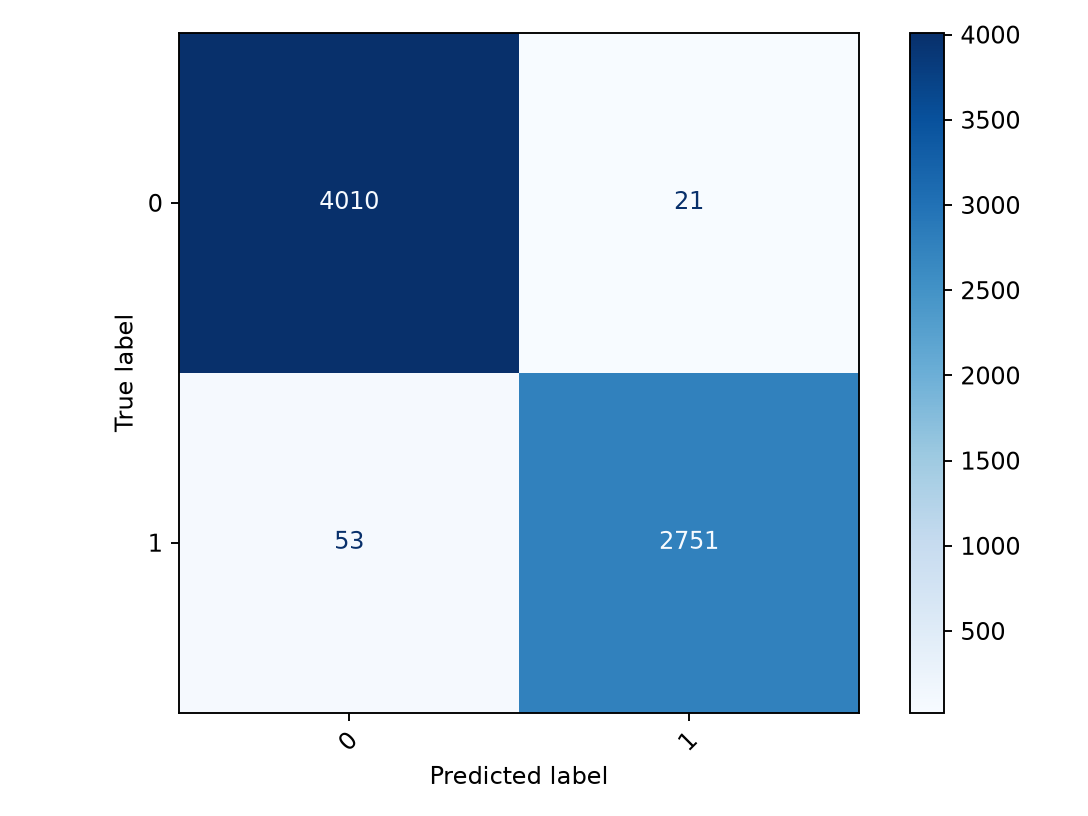

In [3]:
from IPython.display import Image, display

display(Image(filename=str(ROOT / "reports/confusion_text.png")))

## 4. Análisis de errores (74 casos categorizados)

Categorías asignadas tras leer el texto completo de cada error — ver `docs/analisis_errores.md` para la interpretación completa.

In [4]:
errors = pd.read_csv(ROOT / "reports/error_analysis.csv")
print("Total de errores en el conjunto de prueba:", len(errors))
errors["category"].value_counts()

Total de errores en el conjunto de prueba: 74


category
ensayo IA en registro formal/competente, sin marca aparente (caso dificil, cerca del limite de decision)    32
texto humano muy estructurado/formal (parece IA)                                                            18
registro informal/jerga (IA imita habla casual)                                                             14
errores ortograficos insertados artificialmente                                                              4
registro informal + errores insertados (IA imita humano)                                                     3
estructura formal con cita (humano parece IA)                                                                3
Name: count, dtype: int64

In [5]:
pd.set_option("display.max_colwidth", 160)
errors.groupby("category").apply(lambda g: g.head(2))[["real", "predicted", "text"]]

C:\Users\alexb\AppData\Local\Temp\ipykernel_39784\2270855060.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  errors.groupby("category").apply(lambda g: g.head(2))[["real", "predicted", "text"]]


real  \
category                                                                                                            
ensayo IA en registro formal/competente, sin marca aparente (caso dificil, cerca del limite de decision) 2      1   
                                                                                                         4      1   
errores ortograficos insertados artificialmente                                                          14     1   
                                                                                                         32     1   
estructura formal con cita (humano parece IA)                                                            6      0   
                                                                                                         9      0   
registro informal + errores insertados (IA imita humano)                                                 3      1   
                                                                                                         18     1   
registro informal/jerga (IA imita habla casual)                                                          1      1   
                                                                                                         8      1   
texto humano muy estructurado/formal (parece IA)                                                         0      0   
                                                                                                         7      0   

                                                                                                             predicted  \
category                                                                                                                 
ensayo IA en registro formal/competente, sin marca aparente (caso dificil, cerca del limite de decision) 2           0   
                                                                                                         4           0   
errores ortograficos insertados artificialmente                                                          14          0   
                                                                                                         32          0   
estructura formal con cita (humano parece IA)                                                            6           1   
                                                                                                         9           1   
registro informal + errores insertados (IA imita humano)                                                 3           0   
                                                                                                         18          0   
registro informal/jerga (IA imita habla casual)                                                          1           0   
                                                                                                         8           0   
texto humano muy estructurado/formal (parece IA)                                                         0           1   
                                                                                                         7           1   

                                                                                                                                                                                                                                                                        text  
category                                                                                                                                                                                                                                                                      
ensayo IA en registro formal/competente, sin marca aparente (caso dificil, cerca del limite de decision) 2   There are three reasons why I agree that it is more important for students to understand ideas and concepts th

## 5. Modelo guardado: predicciones de verificación

Incluye los tres casos fuera de lo esperado que se probaron manualmente en la app de Streamlit (español, inglés casual fuera de dominio, inglés formal corto) para mostrar que el modelo nunca se abstiene — siempre fuerza una respuesta entre las dos clases.

In [6]:
import joblib

model = joblib.load(ROOT / "models/text_model.joblib")

casos = [
    "Excelente servicio",
    "Today, we are waiting for the news from London, while we are waiting, we must go for a pizza.",
    "I believe that students should not be allowed to use cell phones during class because it distracts them from learning and reduces their attention span.",
]
for texto, pred in zip(casos, model.predict(casos)):
    print(f"[{pred}] {texto}")

[1] Excelente servicio
[1] Today, we are waiting for the news from London, while we are waiting, we must go for a pizza.
[1] I believe that students should not be allowed to use cell phones during class because it distracts them from learning and reduces their attention span.


## 6. Síntesis

Ver la sección **"Cierre interpretativo"** en `README.md` para la interpretación completa (resultado principal, clase con mayor dificultad, limitaciones del dataset y decisión antes del despliegue).